# DDPM & DDIM on MNIST

implementing an unconditional Diffusion Model using DDPM and DDIM sampling on the MNIST dataset

In [1]:
%pip install -q -U torch torchvision matplotlib numpy tqdm

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Params

In [3]:
batch_size = 128
n_epochs = 10
lr = 2e-4
n_timesteps = 1000
beta_start = 1e-4
beta_end = 0.02
image_size = 32
channels = 1

## Data loading

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

## U-Net architecture

simple U-Net with time embeddings

In [5]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = np.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        
        if up:
            self.conv1 = nn.Conv2d(2 * in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
        
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU()

    def forward(self, x, t):
        h = self.bnorm1(self.relu(self.conv1(x)))
        
        # time embedding
        time_emb = self.relu(self.time_mlp(t))
        time_emb = time_emb[(..., ) + (None, ) * 2]
        h = h + time_emb
        
        h = self.bnorm2(self.relu(self.conv2(h)))
        
        return self.transform(h)


class SimpleUnet(nn.Module):
    def __init__(self):
        super().__init__()
        image_channels = 1
        down_channels = (64, 128, 256, 512, 1024)
        up_channels = (1024, 512, 256, 128, 64)
        out_dim = 1
        time_emb_dim = 32

        # embedding MLP
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )
        
        self.conv0 = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)
        self.downs = nn.ModuleList([
            Block(down_channels[i], down_channels[i + 1], time_emb_dim)
            for i in range(len(down_channels) - 1)
        ])
        self.ups = nn.ModuleList([
            Block(up_channels[i], up_channels[i + 1], time_emb_dim, up=True)
            for i in range(len(up_channels) - 1)
        ])
        self.output = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, timestep):
        t = self.time_mlp(timestep)
        x = self.conv0(x)
        
        residual_inputs = []
        for down in self.downs:
            x = down(x, t)
            residual_inputs.append(x)
        
        for up in self.ups:
            residual_x = residual_inputs.pop()
            x = torch.cat((x, residual_x), dim=1)
            x = up(x, t)
        
        return self.output(x)

## DDPM scheduler

In [6]:
class DDPMScheduler:
    def __init__(self, n_timesteps=1000, beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.n_timesteps = n_timesteps
        self.betas = torch.linspace(beta_start, beta_end, n_timesteps).to(device)
        self.alphas = 1. - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, axis=0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod)
        self.device = device

    def add_noise(self, x_0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_0)
        
        sqrt_alphas_cumprod_t = self.sqrt_alphas_cumprod[t][:, None, None, None]
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
        
        noisy_x = sqrt_alphas_cumprod_t * x_0 + sqrt_one_minus_alphas_cumprod_t * noise
        return noisy_x, noise

    def sample(self, model, n_samples, channels, image_size):
        model.eval()
        with torch.no_grad():
            x = torch.randn((n_samples, channels, image_size, image_size)).to(self.device)
            
            for i in tqdm(reversed(range(self.n_timesteps)), desc='DDPM Sampling', total=self.n_timesteps):
                t = torch.full((n_samples,), i, dtype=torch.long, device=self.device)
                predicted_noise = model(x, t)
                
                alpha = self.alphas[i]
                alpha_cumprod = self.alphas_cumprod[i]
                beta = self.betas[i]
                
                noise = torch.randn_like(x) if i > 0 else torch.zeros_like(x)
                
                mean_coef = 1 / torch.sqrt(alpha)
                noise_coef = (1 - alpha) / torch.sqrt(1 - alpha_cumprod)
                x = mean_coef * (x - noise_coef * predicted_noise) + torch.sqrt(beta) * noise
        
        model.train()
        x = (x.clamp(-1, 1) + 1) / 2
        
        return x

## Training

In [7]:
model = SimpleUnet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = DDPMScheduler(
    n_timesteps=n_timesteps,
    beta_start=beta_start,
    beta_end=beta_end,
    device=device
)
criterion = nn.MSELoss()

for epoch in range(n_epochs):
    model.train()
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{n_epochs}")
    
    for step, (images, _) in enumerate(pbar):
        images = images.to(device)
        batch_size = images.shape[0]
        
        t = torch.randint(0, n_timesteps, (batch_size,), device=device).long()
        noisy_images, noise = scheduler.add_noise(images, t)
        noise_pred = model(noisy_images, t)
        loss = criterion(noise_pred, noise)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        pbar.set_postfix(loss=loss.item())
    
    torch.save(model.state_dict(), f"ddpm_mnist_epoch_{epoch}.pth")

Epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 3/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 4/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 5/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 6/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 7/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 8/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

## DDPM sampling

DDPM Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

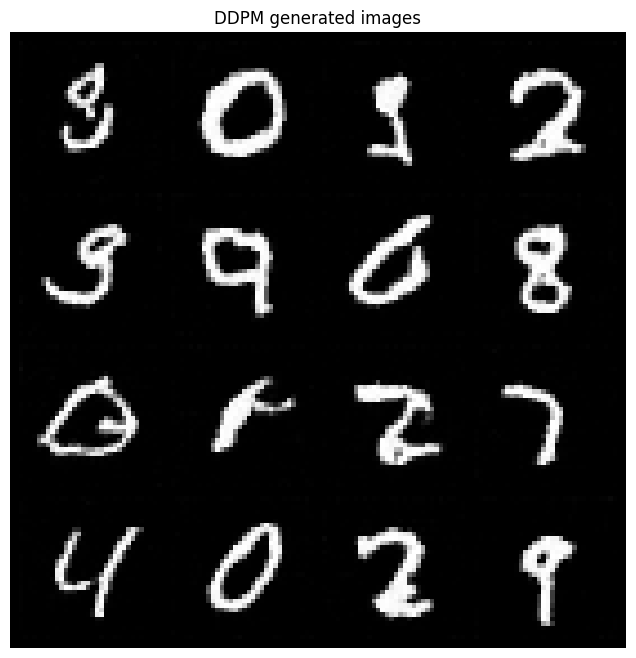

In [12]:
samples_ddpm = scheduler.sample(model, n_samples=16, channels=channels, image_size=image_size)

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("DDPM generated images")
plt.imshow(make_grid(samples_ddpm.cpu(), nrow=4).permute(1, 2, 0))

## DDIM sampling


In [9]:
def ddim_sample(model, n_samples, channels, image_size, ddim_timesteps=50, eta=0.0):
    c = n_timesteps // ddim_timesteps
    time_steps = torch.arange(0, n_timesteps, c).long().to(device)
    time_steps = time_steps.flip(0)
    
    model.eval()
    with torch.no_grad():
        x = torch.randn((n_samples, channels, image_size, image_size)).to(device)
        
        for i, t_curr in enumerate(tqdm(time_steps, desc='DDIM sampling')):
            if i < len(time_steps) - 1:
                t_prev = time_steps[i + 1]
            else:
                t_prev = -1
            
            t_tensor = torch.full((n_samples,), t_curr, dtype=torch.long, device=device)
            noise_pred = model(x, t_tensor)
            
            alpha_cumprod_t = scheduler.alphas_cumprod[t_curr]
            if t_prev >= 0:
                alpha_cumprod_t_prev = scheduler.alphas_cumprod[t_prev]
            else:
                alpha_cumprod_t_prev = torch.tensor(1.0).to(device)
            
            pred_x0 = (x - torch.sqrt(1 - alpha_cumprod_t) * noise_pred) / torch.sqrt(alpha_cumprod_t)
            pred_x0 = torch.clamp(pred_x0, -1, 1)
            
            pred_noise_clipped = (x - torch.sqrt(alpha_cumprod_t) * pred_x0) / torch.sqrt(1 - alpha_cumprod_t)
            
            sigma_t = eta * torch.sqrt(
                (1 - alpha_cumprod_t_prev) / (1 - alpha_cumprod_t) * 
                (1 - alpha_cumprod_t / alpha_cumprod_t_prev)
            )
            
            if eta == 0:
                x = torch.sqrt(alpha_cumprod_t_prev) * pred_x0 + \
                    torch.sqrt(1 - alpha_cumprod_t_prev) * pred_noise_clipped
            else:
                noise = torch.randn_like(x)
                dir_xt = torch.sqrt(1 - alpha_cumprod_t_prev - sigma_t**2) * pred_noise_clipped
                x = torch.sqrt(alpha_cumprod_t_prev) * pred_x0 + dir_xt + sigma_t * noise
    
    model.train()
    x = (x.clamp(-1, 1) + 1) / 2
    return x

DDIM sampling:   0%|          | 0/50 [00:00<?, ?it/s]

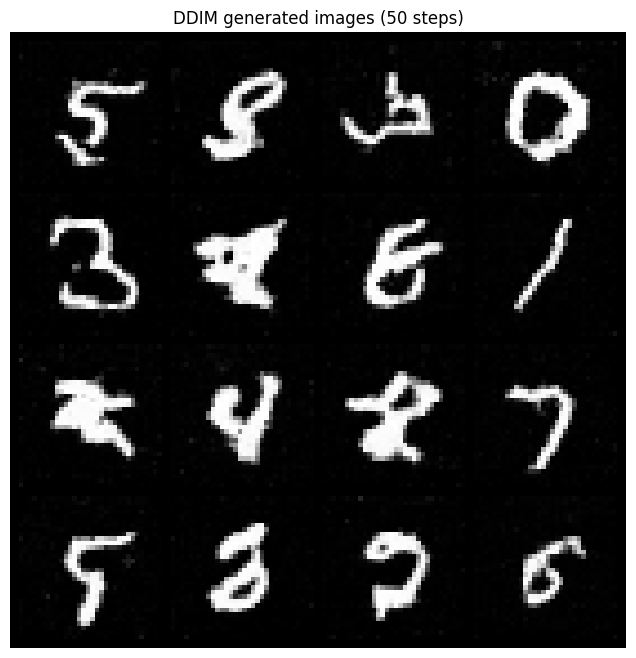

In [15]:
samples_ddim = ddim_sample(model, n_samples=16, channels=channels, image_size=image_size, ddim_timesteps=50, eta=0.0)

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("DDIM generated images (50 steps)")
plt.imshow(make_grid(samples_ddim.cpu(), nrow=4).permute(1, 2, 0))

## Comparison

generation quality via step count

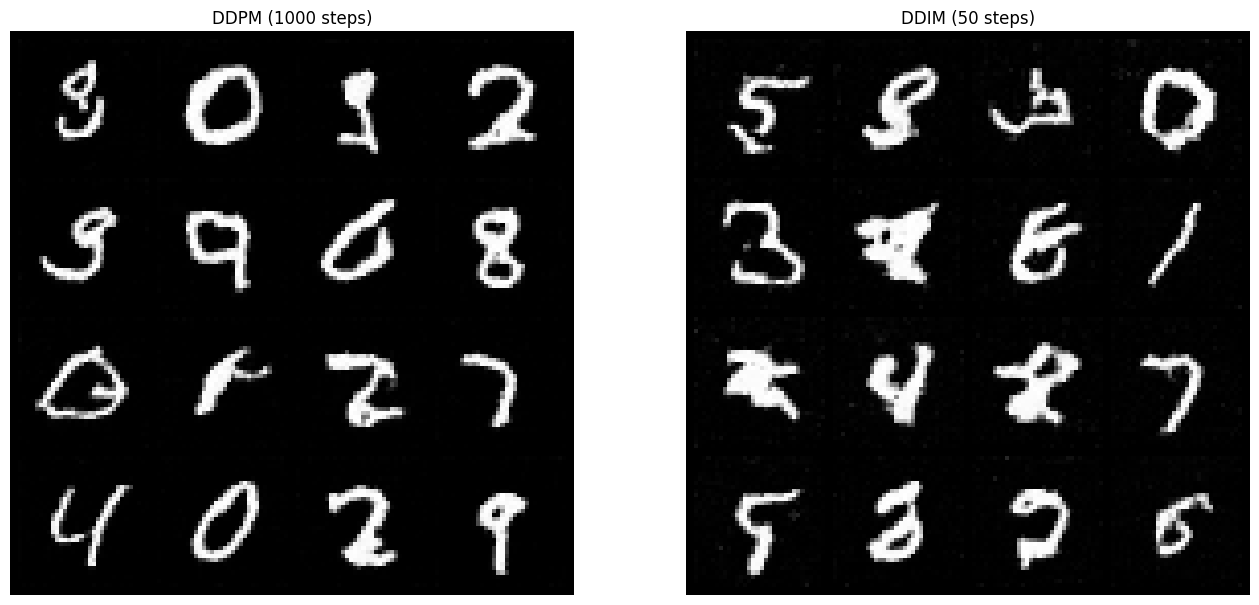

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

axs[0].imshow(make_grid(samples_ddpm.cpu(), nrow=4).permute(1, 2, 0))
axs[0].set_title("DDPM (1000 steps)")
axs[0].axis('off')

axs[1].imshow(make_grid(samples_ddim.cpu(), nrow=4).permute(1, 2, 0))
axs[1].set_title("DDIM (50 steps)")
axs[1].axis('off')

plt.show()